## Import and Load data

In [1]:
from qualibrate import QualibrationNode
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import json
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path


2026-03-22 00:25:44,781 - qm - INFO     - Starting session: c2872653-a683-467f-86d6-61ded8568442


In [29]:
id_qpt, id_gst, id_ell = 946, 781, 948
gst_depth = 4
node = QualibrationNode('robustness_to_fidelity')
data_path = Path("data/gst_qpt_ellipsoid").resolve()
da_gst = node.load_from_id(id_gst, base_path=data_path).results['ds'].sel(depth=gst_depth).sel(model_type='CPTP').robustness
da_qpt = node.load_from_id(id_qpt, base_path=data_path).results['ds'].sel(model_type='mitigated').robustness
da_ell = node.load_from_id(id_ell, base_path=data_path).results['ds'].robustness
da_fid = node.load_from_id(id_qpt, base_path=data_path).results['ds'].sel(model_type='mitigated').fidelity

da_gst = da_gst.assign_coords(fidelity=da_fid)
da_qpt = da_qpt.assign_coords(fidelity=da_fid)


da_fid_aligned = da_fid.reindex_like(da_ell, method='nearest')
da_ell = da_ell.assign_coords(fidelity=da_fid_aligned)
da_ell

2026-03-22 00:38:47,444 - qualibrate - INFO - Creating node robustness_to_fidelity


<xarray.DataArray 'robustness' (alpha: 24)> Size: 192B
[24 values with dtype=float64]
Coordinates:
  * alpha       (alpha) float64 192B 1.0 1.01 1.02 1.03 ... 1.2 1.21 1.22 1.23
    fidelity    (alpha) float64 192B ...
    model_type  <U9 36B 'mitigated'

In [34]:
da_qpt

<xarray.DataArray 'robustness' (alpha: 31)> Size: 248B
array([0.906066, 0.869272, 0.890266, 0.877248, 0.858507, 0.881054, 0.827859,
       0.827001, 0.8248  , 0.785931, 0.822493, 0.783192, 0.788526, 0.788356,
       0.726331, 0.740223, 0.740823, 0.708825, 0.733456, 0.712292, 0.691745,
       0.68769 , 0.666112, 0.689701, 0.65734 , 0.661474, 0.665133, 0.649369,
       0.650198, 0.676238, 0.649404])
Coordinates:
  * alpha       (alpha) float64 248B 1.0 1.01 1.02 1.03 ... 1.27 1.28 1.29 1.3
    fidelity    (alpha) float64 248B 0.9903 0.9853 0.9907 ... 0.7815 0.7502
    model_type  <U9 36B 'mitigated'

In [35]:
da_ell

<xarray.DataArray 'robustness' (alpha: 24)> Size: 192B
array([0.986097, 0.981259, 0.988775, 0.99661 , 0.994505, 0.997341, 0.996223,
       0.997429, 0.998852, 0.994888, 0.999807, 0.993305, 0.987197, 0.984625,
       0.987629, 0.989298, 0.98598 , 0.991953, 0.993372, 0.98616 , 0.992557,
       0.995076, 0.992564, 0.994942])
Coordinates:
  * alpha       (alpha) float64 192B 1.0 1.01 1.02 1.03 ... 1.2 1.21 1.22 1.23
    fidelity    (alpha) float64 192B 0.9903 0.9853 0.9907 ... 0.863 0.8492
    model_type  <U9 36B 'mitigated'

## qpt vs ellipsoid

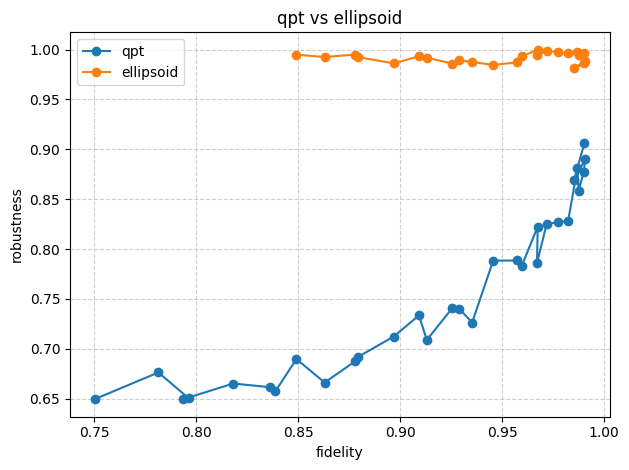

In [30]:
da_qpt.plot.line(
    x='fidelity',
    marker='o',
    linewidth=1.5,
    label='qpt'
)
da_ell.plot.line(
    x='fidelity',
    marker='o',
    linewidth=1.5,
    label='ellipsoid'
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.title('qpt vs ellipsoid')
plt.show()


## gst vs ellipsoid

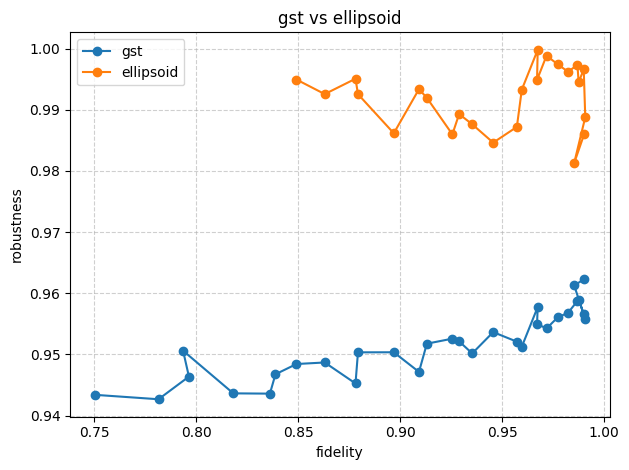

In [32]:
da_gst.plot.line(
    x='fidelity',
    marker='o',
    linewidth=1.5,
    label='gst'
)
da_ell.plot.line(
    x='fidelity',
    marker='o',
    linewidth=1.5,
    label='ellipsoid'
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.title('gst vs ellipsoid')
plt.show()

## gst, qpt ellipsoid

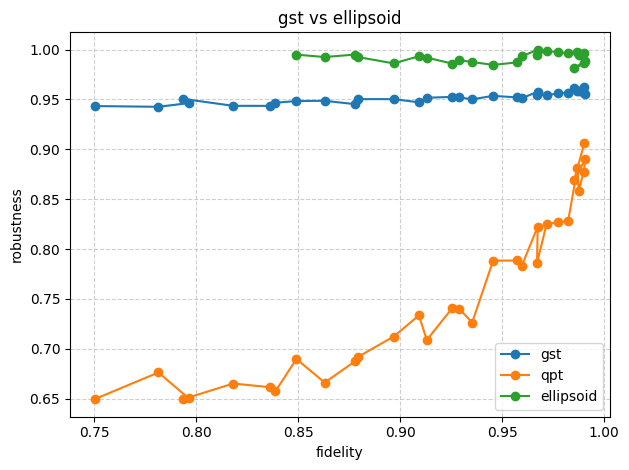

In [33]:
da_gst.plot.line(
    x='fidelity',
    marker='o',
    linewidth=1.5,
    label='gst'
)
da_qpt.plot.line(
    x='fidelity',
    marker='o',
    linewidth=1.5,
    label='qpt'
)
da_ell.plot.line(
    x='fidelity',
    marker='o',
    linewidth=1.5,
    label='ellipsoid'
)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.legend()
plt.title('gst vs ellipsoid')
plt.show()